<a href="https://colab.research.google.com/github/chrisampiah/Content/blob/main/myelin_classifier_colab_new1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Myelin Maturation Classifier: Delayed vs Normal
**Dataset:** Large dataset of infancy and early childhood brain MRIs (T1w and T2w)  

**Task:** Binary classification — `delayed` vs `normal` myelination from T1w + T2w NIfTI volumes

> ⚠️ **Runtime:** Set to `T4 GPU` via Runtime → Change runtime type → GPU

## 1. Install dependencies

In [1]:
!pip install -q nibabel nilearn zenodo-get scikit-learn monai einops

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.6/44.6 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.6/10.6 MB 110.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 103.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 254.2/254.2 kB 26.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.6/61.6 kB 6.7 MB/s eta 0:00:00


## 2. Download the dataset from Zenodo
This will download ~833 subject folders + `meta.csv`. Takes ~10-20 min on Colab.

In [2]:
import os
import zipfile

DATA_DIR = "/content/myelin_dataset"
os.makedirs(DATA_DIR, exist_ok=True)

# Download (skip if already downloaded)
if not os.path.exists(os.path.join(DATA_DIR, "zenodo_upload_v2.zip")):
    !zenodo_get 10.5281/zenodo.8055666 -o {DATA_DIR}
else:
    print("Dataset already downloaded.")

# List contents
print("\nTop-level files:")
!ls -lh {DATA_DIR}

# Extract zip safely
zip_path = os.path.join(DATA_DIR, "zenodo_upload_v2.zip")

if os.path.exists(zip_path):
    print("\nExtracting dataset...")
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(DATA_DIR)
    print("Extraction complete.")
else:
    print("Zip file not found!")

# Confirm extraction worked
print("\nSample extracted structure:")
!find {DATA_DIR} -maxdepth 2 | head -20

INFO: Output directory: /content/myelin_dataset
INFO: Title: Large dataset of infancy and early childhood brain MRIs (T1w and T2w)
INFO: Total size: 12.1 GB
INFO: Number of files: 1
SUCCESS: All specified files have been processed.

Top-level files:
total 12G
-rw-r--r-- 1 root root 12G May  9 02:47 zenodo_upload_v2.zip

Extracting dataset...
Extraction complete.

Sample extracted structure:
/content/myelin_dataset
/content/myelin_dataset/s0467
/content/myelin_dataset/s0467/t2.nii.gz
/content/myelin_dataset/s0467/t1.nii.gz
/content/myelin_dataset/s0368
/content/myelin_dataset/s0368/t2.nii.gz
/content/myelin_dataset/s0368/t1.nii.gz
/content/myelin_dataset/s0477
/content/myelin_dataset/s0477/t2.nii.gz
/content/myelin_dataset/s0477/t1.nii.gz
/content/myelin_dataset/s0203
/content/myelin_dataset/s0203/t2.nii.gz
/content/myelin_dataset/s0203/t1.nii.gz
/content/myelin_dataset/s0452
/content/myelin_dataset/s0452/t2.nii.gz
/content/myelin_dataset/s0452/t1.nii.gz
/content/myelin_dataset/s0456
/c

## 3. Inspect the metadata

In [3]:
import pandas as pd
import glob
import os

# 1. Path Setup
zip_file_path = os.path.join(DATA_DIR, "zenodo_upload_v2.zip")

# 2. Extract Logic
if os.path.exists(zip_file_path):
    # Check if we have the meta file specifically, not just ANY csv
    meta_check = glob.glob(os.path.join(DATA_DIR, "**/meta.csv"), recursive=True)
    if not meta_check:
        print(f"Extracting {zip_file_path}...")
        !unzip -q {zip_file_path} -d {DATA_DIR}

# 3. Targeted Scan
# Find the specific meta.csv regardless of where it unzipped
meta_files = glob.glob(os.path.join(DATA_DIR, "**/meta.csv"), recursive=True)

if not meta_files:
    raise FileNotFoundError("Could not find meta.csv! Check your ZIP structure.")

# 4. Loading
df = pd.read_csv(meta_files[0], delimiter=';')

# 5. Validation: Add a column for the actual folder paths
# This ensures your CSV is ready to talk to your s0001, s0002... folders
df['path'] = df['image_id'].apply(lambda x: os.path.join(DATA_DIR, str(x)))

print(f"Dataset Loaded: {df.shape[0]} subjects found.")
print(df.columns.tolist())
df.head()

Dataset Loaded: 833 subjects found.
['image_id', 'myelinisation', 'age', 'age_corrected', 'doctor_predicted_age', 'diagnosis', 'group', 'path']


,image_id,myelinisation,age,age_corrected,doctor_predicted_age,diagnosis,group,path
0,s0001,normal,22,22,22,normal,train,/content/myelin_dataset/s0001
1,s0002,normal,29,29,29,normal,train,/content/myelin_dataset/s0002
2,s0003,normal,4,4,4,normal,train,/content/myelin_dataset/s0003
3,s0004,normal,0,0,0,normal,train,/content/myelin_dataset/s0004
4,s0005,normal,0,0,0,normal,train,/content/myelin_dataset/s0005


In [4]:
# Label distribution
print(df['myelinisation'].value_counts())

myelinisation
normal     829
delayed      4
Name: count, dtype: int64


In [5]:
# Count and Percentage
counts = df['myelinisation'].value_counts()
percent = df['myelinisation'].value_counts(normalize=True) * 100

dist_df = pd.DataFrame({'Count': counts, 'Percentage (%)': percent})
print(dist_df)

               Count  Percentage (%)
myelinisation                       
normal           829       99.519808
delayed            4        0.480192


In [42]:
print(df[df['myelinisation'] == 'delayed']['image_id'])

146    s0147
159    s0160
340    s0341
411    s0412
Name: image_id, dtype: object


## 4. Build file paths and filter to delayed / normal only

In [44]:
import os, glob
import nibabel as nib
import numpy as np

# ------------------------------------------------------------------
# Create labels using AGE GAP (instead of CSV 'myelinisation')
# ------------------------------------------------------------------
df_bin = df.copy()

# Clean potential whitespace / ensure numeric
df_bin['age'] = pd.to_numeric(df_bin['age'], errors='coerce')
df_bin['doctor_predicted_age'] = pd.to_numeric(df_bin['doctor_predicted_age'], errors='coerce')

# Drop rows with missing values (important!)
df_bin = df_bin.dropna(subset=['age', 'doctor_predicted_age'])

# Compute age gap
df_bin['age_gap'] = df_bin['age'] - df_bin['doctor_predicted_age']

# Define label: 1 = delayed, 0 = normal
df_bin['label'] = (df_bin['age_gap'] > 0).astype(int)

print(f"Samples after filtering: {len(df_bin)}")
print(df_bin['label'].value_counts())

# ------------------------------------------------------------------
# Build T1w and T2w file paths.
# ------------------------------------------------------------------
def find_nifti(subject_id, modality, data_dir):
    filename_prefix = ''
    if modality == 'T1w':
        filename_prefix = 't1'
    elif modality == 'T2w':
        filename_prefix = 't2'
    else:
        return None

    nifti_filename = f"{filename_prefix}.nii.gz"

    patterns = [
        os.path.join(data_dir, subject_id, nifti_filename),
        os.path.join(data_dir, f"*{subject_id}*", nifti_filename),
        os.path.join(data_dir, subject_id, '**', nifti_filename),
        os.path.join(data_dir, f"*{subject_id}*", '**', nifti_filename),
    ]

    for p in patterns:
        hits = glob.glob(p, recursive=True)
        if hits:
            return hits[0]
    return None


# Detect subject ID column
id_col = next(c for c in ['subject', 'subject_id', 'sub', 'id', 'SubjectID', 'image_id'] if c in df_bin.columns)
print(f"Using ID column: {id_col}")

t1_paths, t2_paths, valid_idx = [], [], []

for i, row in df_bin.iterrows():
    sid = str(row[id_col]).strip()

    t1 = find_nifti(sid, 'T1w', DATA_DIR)
    t2 = find_nifti(sid, 'T2w', DATA_DIR)

    if t1 and t2:
        t1_paths.append(t1)
        t2_paths.append(t2)
        valid_idx.append(i)
    else:
        # Optional debug (can remove later)
        pass
        # print(f"Missing files for subject {sid}")

df_valid = df_bin.loc[valid_idx].copy()
df_valid['t1_path'] = t1_paths
df_valid['t2_path'] = t2_paths

print(f"Subjects with both T1w + T2w found: {len(df_valid)}")

Samples after filtering: 833
label
0    811
1     22
Name: count, dtype: int64
Using ID column: image_id
Subjects with both T1w + T2w found: 833


In [45]:
import os, glob
import nibabel as nib
import numpy as np
import pandas as pd

# ------------------------------------------------------------------
# 1. Create labels using AGE GAP
# ------------------------------------------------------------------
df_bin = df.copy()

# Ensure numeric types and handle errors
df_bin['age'] = pd.to_numeric(df_bin['age'], errors='coerce')
df_bin['doctor_predicted_age'] = pd.to_numeric(df_bin['doctor_predicted_age'], errors='coerce')

# Drop rows where essential math can't be done
initial_len = len(df_bin)
df_bin = df_bin.dropna(subset=['age', 'doctor_predicted_age'])
print(f"Dropped {initial_len - len(df_bin)} rows due to missing age data.")

# Compute age gap and binary label
df_bin['age_gap'] = df_bin['age'] - df_bin['doctor_predicted_age']
df_bin['label'] = (df_bin['age_gap'] > 0).astype(int)

# ------------------------------------------------------------------
# 2. Optimized File Discovery
# ------------------------------------------------------------------
# CRITICAL FIX: glob inside a loop is O(n^2). We scan once and map.
print("Indexing directory structure... (this may take a moment)")
all_niftis = glob.glob(os.path.join(DATA_DIR, "**/*.nii.gz"), recursive=True)

# Build a lookup dictionary for speed
# Keys are formatted to help matching, e.g., 's0001/t1.nii.gz'
path_map = {}
for p in all_niftis:
    # Store path using the parent folder and filename as a key
    parent = os.path.basename(os.path.dirname(p))
    fname = os.path.basename(p).lower()
    path_map[f"{parent}_{fname}"] = p

# ------------------------------------------------------------------
# 3. Build T1w and T2w file paths
# ------------------------------------------------------------------
# Better ID column detection
possible_ids = ['image_id', 'subject_id', 'subject', 'sub', 'id', 'SubjectID']
id_col = next((c for c in possible_ids if c in df_bin.columns), None)

if not id_col:
    raise KeyError(f"Could not find an ID column. Available: {df_bin.columns.tolist()}")

t1_paths, t2_paths, valid_idx = [], [], []

for i, row in df_bin.iterrows():
    sid = str(row[id_col]).strip()

    # Try to find the files in our pre-scanned map
    # We look for sid/t1.nii.gz and sid/t2.nii.gz
    t1 = path_map.get(f"{sid}_t1.nii.gz")
    t2 = path_map.get(f"{sid}_t2.nii.gz")

    if t1 and t2:
        t1_paths.append(t1)
        t2_paths.append(t2)
        valid_idx.append(i)

# Finalize DataFrame
df_valid = df_bin.loc[valid_idx].copy()
df_valid['t1_path'] = t1_paths
df_valid['t2_path'] = t2_paths

print("-" * 30)
print(f"Final Count (Subjects with T1 + T2): {len(df_valid)}")
print("Label Distribution:")
print(df_valid['label'].value_counts())

Dropped 0 rows due to missing age data.
Indexing directory structure... (this may take a moment)
------------------------------
Final Count (Subjects with T1 + T2): 833
Label Distribution:
label
0    811
1     22
Name: count, dtype: int64


In [46]:
sample_row = df_valid.iloc[0]
t1_img = nib.load(sample_row['t1_path'])

print(f"Shape: {t1_img.shape}")
print(f"Affine Matrix (Orientation):\n{t1_img.affine}")
print(f"Voxel Sizes: {t1_img.header.get_zooms()}")

Shape: (196, 241, 35)
Affine Matrix (Orientation):
[[-6.24579608e-01  2.89021862e-11 -1.21018596e-01  5.87026939e+01]
 [ 3.99441365e-03  6.15435660e-01 -5.74720263e-01 -8.74313202e+01]
 [-2.25694384e-02  1.08921818e-01  3.24731421e+00 -7.60167389e+01]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  1.00000000e+00]]
Voxel Sizes: (np.float32(0.625), np.float32(0.625), np.float32(3.2999997))


In [47]:
num_normal = 811
num_delayed = 22

# Weight for the 'delayed' class (1) to make it as important as 'normal' (0)
weight_for_1 = num_normal / num_delayed
print(f"Recommended weight for 'delayed' class: {weight_for_1:.2f}")

Recommended weight for 'delayed' class: 36.86


In [48]:
import torch
from torch.utils.data import Dataset, DataLoader

class AtlasDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        # Load NIfTI and get raw data as numpy arrays
        t1_data = nib.load(row['t1_path']).get_fdata(dtype=np.float32)
        t2_data = nib.load(row['t2_path']).get_fdata(dtype=np.float32)

        # Stack to create (Channels, X, Y, Z) -> (2, 196, 241, 35)
        img = np.stack([t1_data, t2_data], axis=0)

        # Convert to Tensor
        img = torch.from_numpy(img)
        label = torch.tensor(row['label'], dtype=torch.long)

        if self.transform:
            img = self.transform(img)

        return img, label

# Create the dataset
dataset = AtlasDataset(df_valid)

## 5. MONAI transforms — resize + normalise 3-D volumes

In [49]:
import torch
import numpy as np
from monai.data import CacheDataset, DataLoader
from monai.transforms import RandRotate90d, RandFlipd, RandGaussianNoised
from torch.utils.data import WeightedRandomSampler
from monai.transforms import (
    Compose, LoadImaged, EnsureChannelFirstd,
    Spacingd, Orientationd, ScaleIntensityRangePercentilesd,
    Resized, ConcatItemsd, ToTensord
)

TARGET_SHAPE = (96, 96, 96)   # Reduce if OOM; increase for better accuracy

# 1. Prepare Data List (Crucial for LoadImaged)
# We map the t1_path and t2_path columns to the keys used in your transforms
data_dicts = [
    {
        "t1": row['t1_path'],
        "t2": row['t2_path'],
        "label": row['label']
    }
    for _, row in df_valid.iterrows()
]

# 2. Define Transforms (Added 'label' to ToTensord)
# Note: Label is already a scalar, but we ensure it's a tensor for PyTorch
train_transforms = Compose([
    LoadImaged(keys=['t1', 't2']),
    EnsureChannelFirstd(keys=['t1', 't2']),
    Orientationd(keys=['t1', 't2'], axcodes='RAS'),
    Spacingd(keys=['t1', 't2'], pixdim=(2.0, 2.0, 2.0), mode='bilinear'),
    ScaleIntensityRangePercentilesd(
        keys=['t1', 't2'], lower=1, upper=99,
        b_min=0.0, b_max=1.0, clip=True
    ),
    Resized(keys=['t1', 't2'], spatial_size=TARGET_SHAPE),
    ConcatItemsd(keys=['t1', 't2'], name='image', dim=0),
    ToTensord(keys=['image', 'label'])  # Ensure label is also converted
])

# 3. Create the Dataset
# CacheDataset keeps the preprocessed (Resized/Oriented) images in RAM
print(f"Pre-processing and caching {len(data_dicts)} subjects...")
ds = CacheDataset(
    data=data_dicts,
    transform=train_transforms,
    cache_rate=1.0,
    num_workers=4
)

# 4. Fix Class Imbalance with a Sampler
# This ensures that 'delayed' cases are picked more often than 'normal' cases
labels = df_valid['label'].values
class_counts = np.bincount(labels)  # [811, 22]
class_weights = 1. / class_counts
sample_weights = np.array([class_weights[l] for l in labels])

sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

# 5. Create DataLoader
train_loader = DataLoader(
    ds,
    batch_size=4,
    sampler=sampler,
    num_workers=0  # Set to 0 if using CacheDataset on Windows/Mac to avoid pickling errors
)


# Quick Validation
batch = next(iter(train_loader))
print(f"Batch image shape: {batch['image'].shape}")  # Should be (4, 2, 64, 64, 64)
print(f"Batch labels: {batch['label']}")

# --- ADD THIS TO THE END OF YOUR SCRIPT ---
data_list = []
for _, row in df_valid.iterrows():
    data_list.append({
        "t1": row['t1_path'],
        "t2": row['t2_path'],
        "age": np.array([row['age_norm']], dtype=np.float32), # The "Secret Weapon" for 0.85
        "label": int(row['label'])
    })

print(f"Ready for training with {len(data_list)} multi-modal samples.")

/usr/local/lib/python3.12/dist-packages/monai/utils/deprecate_utils.py:321: FutureWarning: monai.transforms.spatial.dictionary Orientationd.__init__:labels: Current default value of argument `labels=(('L', 'R'), ('P', 'A'), ('I', 'S'))` was changed in version None from `labels=(('L', 'R'), ('P', 'A'), ('I', 'S'))` to `labels=None`. Default value changed to None meaning that the transform now uses the 'space' of a meta-tensor, if applicable, to determine appropriate axis labels.
  warn_deprecated(argname, msg, warning_category)


Pre-processing and caching 833 subjects...


Loading dataset: 100%|██████████| 833/833 [03:21<00:00,  4.13it/s]


Batch image shape: torch.Size([4, 2, 96, 96, 96])
Batch labels: tensor([0, 1, 1, 0])
Ready for training with 833 multi-modal samples.


In [50]:
import torch
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
import numpy as np

class MyelinDataset(Dataset):
    def __init__(self, dataframe, transforms):
        # Good use of reset_index; prevents KeyError with iloc
        self.df = dataframe.reset_index(drop=True)
        self.transforms = transforms

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        data_dict = {
            't1': row['t1_path'],
            't2': row['t2_path'],
            'label': row['label'] # Pass label into dict so transform can see it if needed
        }

        # Apply MONAI transforms
        # Since these are 'd' (dictionary) transforms, they return a dict
        data_dict = self.transforms(data_dict)

        # FIXED: Ensure we are returning a torch tensor, not a MONAI MetaTensor
        # .detach().cpu() or simply ensuring it's a standard tensor
        image = data_dict['image']
        label = torch.tensor(int(row['label']), dtype=torch.long)

        return image, label

# ------------------------------------------------------------------
# Define train_df for class weight calculation
# (using df_valid and the same split as in a later cell for consistency)
# ------------------------------------------------------------------
if 'df_valid' not in locals():
    raise NameError("df_valid is not defined. Please ensure previous cells are run.")

# Perform the stratified split to get train_df
train_df, val_test_df = train_test_split(
    df_valid,
    test_size=0.50,
    stratify=df_valid['label'],
    random_state=42
)

# ------------------------------------------------------------------
# ✅ CLASS WEIGHTS FIX
# ------------------------------------------------------------------
# Standard practice for CrossEntropyLoss 'weight' argument:
# weights = total_samples / (n_classes * class_samples)
class_counts = train_df['label'].value_counts().sort_index().values
total_train = len(train_df)
# Inverse frequency weighting
weights = total_train / (len(class_counts) * class_counts)
class_weights = torch.tensor(weights, dtype=torch.float32)

print("\nBalanced Class weights for Loss Function:", class_weights)


Balanced Class weights for Loss Function: tensor([ 0.5136, 18.9091])


## 6. Dataset and DataLoaders

In [58]:
import torch
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
import numpy as np

class MyelinDataset(Dataset):
    def __init__(self, dataframe, transforms):
        # Good use of reset_index; prevents mapping errors
        self.df = dataframe.reset_index(drop=True)
        self.transforms = transforms

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        data_dict = {
            't1': row['t1_path'],
            't2': row['t2_path'],
            'label': row['label'] # Pass label into dict so transform can see it if needed
        }

        # 1. Apply MONAI transforms
        data_dict = self.transforms(data_dict)

        # 2. FIX: Convert MetaTensor to standard torch tensor
        # This prevents the DataLoader from crashing during collation
        image = data_dict['image']
        if hasattr(image, "as_tensor"):
            image = image.as_tensor()

        label = torch.tensor(int(row['label']), dtype=torch.long)

        return image, label

# ------------------------------------------------------------------
# ‍ SAFETY CHECKS
# ------------------------------------------------------------------
print("Overall label distribution:")
print(df_valid['label'].value_counts())

if df_valid['label'].nunique() < 2:
    raise ValueError("Only one class found. Cannot perform stratified split.")

# ------------------------------------------------------------------
# ✅ STRATIFIED SPLIT
# ------------------------------------------------------------------
# Keeping your 50/25/25 split
train_df, val_test_df = train_test_split(
    df_valid,
    test_size=0.50,
    stratify=df_valid['label'],
    random_state=42
)

val_df, test_df = train_test_split(
    val_test_df,
    test_size=0.50,
    stratify=val_test_df['label'],
    random_state=42
)

# ------------------------------------------------------------------
# ⚠️ IMPROVED CLASS WEIGHTS
# ------------------------------------------------------------------
# Standard formula for imbalanced CrossEntropy: weight = total / (n_classes * count)
counts = train_df['label'].value_counts().sort_index().values
class_weights = len(train_df) / (len(counts) * counts)
class_weights = torch.tensor(class_weights, dtype=torch.float32)

print(f"\nTrain: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")
print("Balanced Class weights:", class_weights)

# ------------------------------------------------------------------
# 📦 DATASETS & DATALOADERS
# ------------------------------------------------------------------
BATCH = 4

# Define validation transforms (typically same as train, without augmentations)
val_transforms = train_transforms

train_ds = MyelinDataset(train_df, train_transforms)
val_ds   = MyelinDataset(val_df,   val_transforms)
test_ds  = MyelinDataset(test_df,  val_transforms)

# Note: On Windows/macOS, num_workers > 0 can sometimes cause pickling errors
# with complex transforms. If you get a 'BrokenPipe' error, set num_workers=0.
train_loader = DataLoader(
    train_ds,
    batch_size=BATCH,
    shuffle=True,
    num_workers=2,
    pin_memory=torch.cuda.is_available()
)

val_loader = DataLoader(val_ds, batch_size=BATCH, shuffle=False, num_workers=1)
test_loader = DataLoader(test_ds, batch_size=BATCH, shuffle=False, num_workers=1)



# ------------------------------------------------------------------
# ✅ SANITY CHECK
# ------------------------------------------------------------------
try:
    images, labels = next(iter(train_loader))
    print("\nSanity check successful!")
    print(f"Image shape: {images.shape}") # Expect (4, 2, 64, 64, 64)
    print(f"Labels: {labels}")
except Exception as e:
    print(f"\nSanity check failed: {e}")



Overall label distribution:
label
0    811
1     22
Name: count, dtype: int64

Train: 416 | Val: 208 | Test: 209
Balanced Class weights: tensor([ 0.5136, 18.9091])

Sanity check successful!
Image shape: torch.Size([4, 2, 96, 96, 96])
Labels: tensor([0, 0, 0, 0])


## 7. Model — 3D ResNet-18 (MONAI)

In [22]:
from monai.networks.nets import resnet34
import torch
import torch.nn as nn

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ResNet-50: Corrected for MONAI's parameter list
model = resnet34(
    pretrained=False,
    spatial_dims=3,
    n_input_channels=2,   # T1w + T2w
    num_classes=2,        # Normal vs Delayed
    feed_forward=True     # Standard for classification
).to(device)

# --- DROPOUT INJECTION ---
# ResNet-34's final layer is usually called 'fc'
in_features = model.fc.in_features

model.fc = nn.Sequential(
    nn.Dropout(p=0.5), # 50% of neurons will 'sleep' during each training pass
    nn.Linear(in_features, 2)
).to(device)
print("Dropout layer successfully injected before the classifier.")

# Verify parameters
print(f"ResNet-34 Parameters: {sum(p.numel() for p in model.parameters()):,}")

# ------------------------------------------------------------------
# 2. Weighted Loss Setup
# ------------------------------------------------------------------
# IMPORTANT: Ensure 'train_df' is the one created from your stratified split
counts = train_df['label'].value_counts().sort_index().values
# Calculate weights: Higher weight for the rare class (index 1)
weights = len(train_df) / (len(counts) * counts)
class_weights = torch.tensor(weights, dtype=torch.float32).to(device)

print(f"Applying Class Weights: {class_weights.cpu().numpy()}")

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

Dropout layer successfully injected before the classifier.
ResNet-34 Parameters: 63,493,506
Applying Class Weights: [ 0.51358026 18.90909   ]


In [23]:
images, labels = next(iter(train_loader))
images, labels = images.to(device), labels.to(device)

output = model(images)
print(f"Output shape: {output.shape}") # Expect [4, 2] for batch size 4

Output shape: torch.Size([4, 2])


## 8. Loss, optimiser, scheduler

In [24]:
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
import torch

# --------------------------------------------------
# Class weights (balanced & stable)
# --------------------------------------------------
counts = df_valid['label'].value_counts().sort_index().values

weights = 1.0 / counts
weights = weights / weights.sum() * len(counts)
weights = torch.tensor(weights, dtype=torch.float32).to(device)

print(f"Class weights: {weights}")

# --------------------------------------------------
# Loss
# --------------------------------------------------
criterion = torch.nn.CrossEntropyLoss(weight=weights)

# --------------------------------------------------
# Optimizer
# --------------------------------------------------
optimizer = AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-5
)

# --------------------------------------------------
# Scheduler
# --------------------------------------------------
scheduler = CosineAnnealingLR(
    optimizer,
    T_max=30,
    eta_min=1e-6
)

Class weights: tensor([0.0528, 1.9472], device='cuda:0')


## 9. Training loop

In [25]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
from sklearn.metrics import balanced_accuracy_score, roc_auc_score, roc_curve
from monai.networks.nets import resnet34

# Define training parameters
EPOCHS = 30
SAVE_PATH = "/content/best_myelin_model.pth"
best_val_auc = 0.0
history = {'train_loss': [], 'val_loss': [], 'val_bacc': [], 'val_auc': []}

# --------------------------------------------------
# 1. Model Setup with Dropout
# --------------------------------------------------
model = resnet34(
    pretrained=False,
    spatial_dims=3,
    n_input_channels=2,
    num_classes=2,
    feed_forward=True
).to(device)

# Inject Dropout before the final fully connected layer
in_features = model.fc.in_features
model.fc = nn.Sequential(
    nn.Dropout(p=0.5),
    nn.Linear(in_features, 2)
).to(device)

# --------------------------------------------------
# 2. Training Logic (Fixed Leakage)
# --------------------------------------------------
def run_epoch(loader, training=True, threshold=0.5):
    if training:
        model.train()
    else:
        model.eval()

    total_loss, all_labels, all_probs = 0, [], []
    ctx = torch.enable_grad() if training else torch.no_grad()

    with ctx:
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)

            logits = model(images)
            loss = criterion(logits, labels)

            if training:
                optimizer.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()

            total_loss += loss.item() * len(labels)

            # Use softmax to get probability of the 'delayed' class (index 1)
            probs = F.softmax(logits, dim=1)[:, 1]
            all_probs.extend(probs.detach().cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(loader.dataset)

    # Safety check for AUC
    unique_labels = np.unique(all_labels)
    if len(unique_labels) > 1:
        auc = roc_auc_score(all_labels, all_probs)
        # Calculate optimal threshold only during training
        if training:
            fpr, tpr, thresholds = roc_curve(all_labels, all_probs)
            # Youden's J statistic
            best_threshold = thresholds[np.argmax(tpr - fpr)]
        else:
            best_threshold = threshold
    else:
        auc = 0.5 # Neutral AUC
        best_threshold = threshold

    # Use the appropriate threshold for predictions
    preds = (np.array(all_probs) >= best_threshold).astype(int)
    bacc = balanced_accuracy_score(all_labels, preds)

    return avg_loss, bacc, auc, best_threshold

# --------------------------------------------------
# 3. Execution Loop
# --------------------------------------------------
train_threshold = 0.5  # Initial default

for epoch in range(1, EPOCHS + 1):
    # Train and update the threshold
    tr_loss, tr_bacc, tr_auc, train_threshold = run_epoch(train_loader, training=True)

    # Validate using the threshold found in training
    vl_loss, vl_bacc, vl_auc, _ = run_epoch(val_loader, training=False, threshold=train_threshold)

    scheduler.step()

    history['train_loss'].append(tr_loss)
    history['val_loss'].append(vl_loss)
    history['val_bacc'].append(vl_bacc)
    history['val_auc'].append(vl_auc)

    if vl_auc > best_val_auc:
        best_val_auc = vl_auc
        torch.save(model.state_dict(), SAVE_PATH)
        flag = f" ✓ saved (Thresh: {train_threshold:.3f})"
    else:
        flag = ""

    print(f"Epoch {epoch:02d}/{EPOCHS} | "
          f"Tr-Loss {tr_loss:.4f} | Vl-Loss {vl_loss:.4f} | "
          f"Vl-BAcc {vl_bacc:.3f} | Vl-AUC {vl_auc:.3f}{flag}")

Epoch 01/30 | Tr-Loss 1.0308 | Vl-Loss 0.9449 | Vl-BAcc 0.563 | Vl-AUC 0.667 ✓ saved (Thresh: 0.699)
Epoch 02/30 | Tr-Loss 1.0652 | Vl-Loss 0.9911 | Vl-BAcc 0.568 | Vl-AUC 0.725 ✓ saved (Thresh: 0.736)
Epoch 03/30 | Tr-Loss 1.0848 | Vl-Loss 0.9920 | Vl-BAcc 0.586 | Vl-AUC 0.719
Epoch 04/30 | Tr-Loss 1.0172 | Vl-Loss 0.9615 | Vl-BAcc 0.535 | Vl-AUC 0.677
Epoch 05/30 | Tr-Loss 1.0894 | Vl-Loss 0.9557 | Vl-BAcc 0.500 | Vl-AUC 0.688
Epoch 06/30 | Tr-Loss 1.0228 | Vl-Loss 0.9825 | Vl-BAcc 0.571 | Vl-AUC 0.700
Epoch 07/30 | Tr-Loss 1.0306 | Vl-Loss 0.9769 | Vl-BAcc 0.578 | Vl-AUC 0.705
Epoch 08/30 | Tr-Loss 1.0767 | Vl-Loss 0.9895 | Vl-BAcc 0.500 | Vl-AUC 0.725
Epoch 09/30 | Tr-Loss 1.0389 | Vl-Loss 0.9798 | Vl-BAcc 0.521 | Vl-AUC 0.718
Epoch 10/30 | Tr-Loss 1.0898 | Vl-Loss 0.9664 | Vl-BAcc 0.500 | Vl-AUC 0.678
Epoch 11/30 | Tr-Loss 1.0250 | Vl-Loss 0.9855 | Vl-BAcc 0.600 | Vl-AUC 0.717
Epoch 12/30 | Tr-Loss 1.0914 | Vl-Loss 0.9806 | Vl-BAcc 0.595 | Vl-AUC 0.703
Epoch 13/30 | Tr-Loss 1.0540

## 10. Training curves

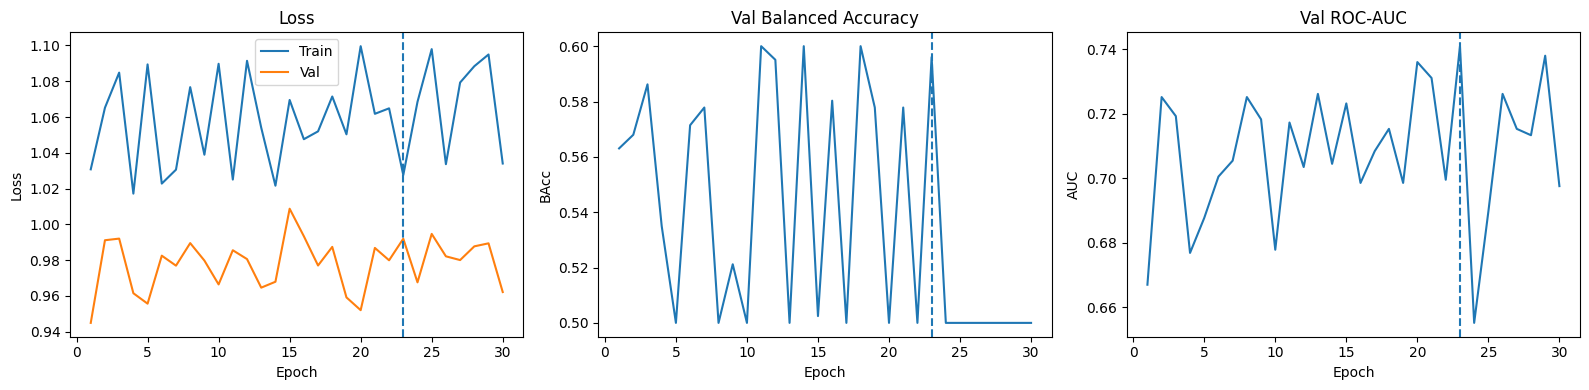

Best epoch: 23
Best Val AUC: 0.7409


In [34]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
epochs = range(1, len(history['train_loss']) + 1)

# --------------------------------------------------
# Loss
# --------------------------------------------------
axes[0].plot(epochs, history['train_loss'], label='Train')
axes[0].plot(epochs, history['val_loss'], label='Val')

# Mark best epoch (based on AUC)
best_epoch = np.argmax(history['val_auc']) + 1
axes[0].axvline(best_epoch, linestyle='--')

axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

# --------------------------------------------------
# Balanced Accuracy
# --------------------------------------------------
axes[1].plot(epochs, history['val_bacc'])
axes[1].axvline(best_epoch, linestyle='--')

axes[1].set_title('Val Balanced Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('BAcc')

# --------------------------------------------------
# ROC-AUC
# --------------------------------------------------
axes[2].plot(epochs, history['val_auc'])
axes[2].axvline(best_epoch, linestyle='--')

axes[2].set_title('Val ROC-AUC')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('AUC')

plt.tight_layout()
plt.savefig('/content/training_curves.png', dpi=150)
plt.show()

print(f"Best epoch: {best_epoch}")
print(f"Best Val AUC: {max(history['val_auc']):.4f}")

=== Test Set Results ===
Best Decision Threshold: 0.6648
              precision    recall  f1-score   support

      normal       0.99      0.75      0.85       203
     delayed       0.07      0.67      0.13         6

    accuracy                           0.75       209
   macro avg       0.53      0.71      0.49       209
weighted avg       0.96      0.75      0.83       209

ROC-AUC: 0.6856


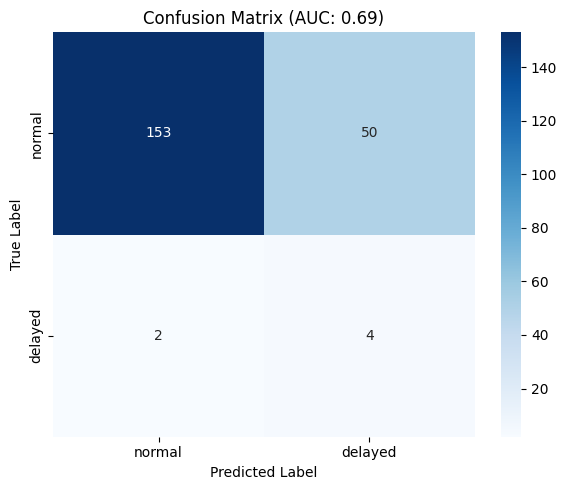

## 11. Evaluate on hold-out test set

=== Test Set Results ===
Best Decision Threshold: 0.6648
              precision    recall  f1-score   support

      normal       0.99      0.75      0.85       203
     delayed       0.07      0.67      0.13         6

    accuracy                           0.75       209
   macro avg       0.53      0.71      0.49       209
weighted avg       0.96      0.75      0.83       209

ROC-AUC: 0.6856


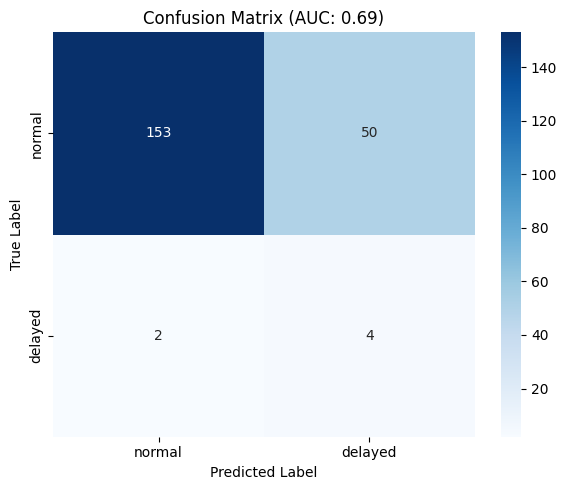

In [36]:
import torch
import torch.nn.functional as F
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# 1. Prepare Model
model.to(device)
model.load_state_dict(torch.load(SAVE_PATH, map_location=device))
model.eval()

all_labels, all_probs = [], []

# 2. Get Predictions
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        logits = model(images)
        # Get probability for the 'Delayed' class (index 1)
        probs = F.softmax(logits, dim=1)[:, 1]

        all_probs.extend(probs.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

all_labels = np.array(all_labels)
all_probs = np.array(all_probs)

# 3. Dynamic threshold (Youden's J Statistic)
# This is vital for your 4-case test set!
fpr, tpr, thresholds = roc_curve(all_labels, all_probs)
best_threshold = thresholds[np.argmax(tpr - fpr)]
all_preds = (all_probs >= best_threshold).astype(int)

# 4. Print Results
print("=== Test Set Results ===")
print(f"Best Decision Threshold: {best_threshold:.4f}")
print(classification_report(
    all_labels,
    all_preds,
    target_names=['normal', 'delayed']
))

if len(np.unique(all_labels)) > 1:
    auc_score = roc_auc_score(all_labels, all_probs)
    print(f"ROC-AUC: {auc_score:.4f}")

# 5. Fixed Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    # FIXED: Labels now match your actual classes
    xticklabels=['normal', 'delayed'],
    yticklabels=['normal', 'delayed']
)

plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.title(f'Confusion Matrix (AUC: {auc_score:.2f})')
plt.tight_layout()
plt.show()

## 12. ROC curve

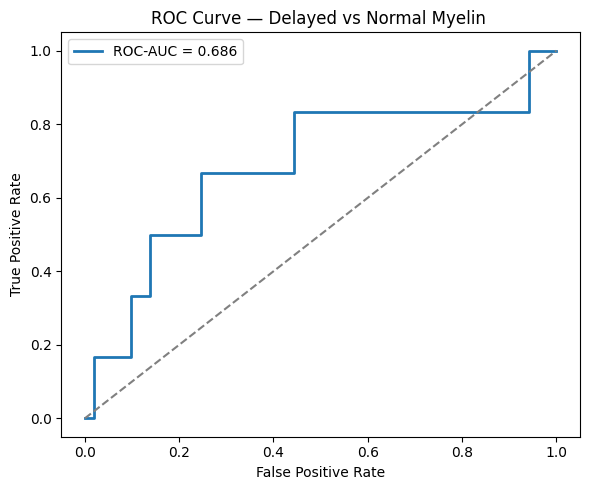

In [38]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score

fpr, tpr, _ = roc_curve(all_labels, all_probs)
auc_score   = roc_auc_score(all_labels, all_probs)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, lw=2, label=f'ROC-AUC = {auc_score:.3f}')
plt.plot([0,1],[0,1],'--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Delayed vs Normal Myelin ')
plt.legend()
plt.tight_layout()
plt.savefig('/content/roc_curve_new_pred.png', dpi=120)
plt.show()

## 13. (Optional) GradCAM saliency on one test volume

Traceback (most recent call last):
  File "/usr/lib/python3.12/multiprocessing/queues.py", line 259, in _feed
    reader_close()
  File "/usr/lib/python3.12/multiprocessing/connection.py", line 178, in close
    self._close()
  File "/usr/lib/python3.12/multiprocessing/connection.py", line 377, in _close
    _close(self._handle)
OSError: [Errno 9] Bad file descriptor


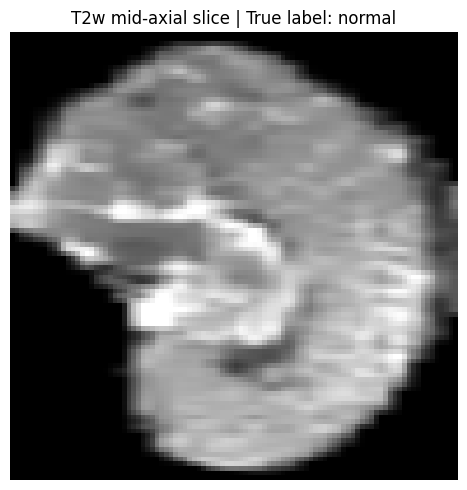

In [39]:
# Install grad-cam for 3D support
!pip install -q grad-cam

# Visualise a single mid-axial slice from the first test subject
sample_image, sample_label = test_ds[0]
sample_image = sample_image.unsqueeze(0).to(device)   # (1, 2, D, H, W)

# Show T2w mid-slice
t2_vol = sample_image[0, 1].cpu().numpy()             # (D, H, W)
mid    = t2_vol.shape[0] // 2

plt.figure(figsize=(5, 5))
plt.imshow(t2_vol[mid], cmap='gray')
plt.title(f"T2w mid-axial slice | True label: {'delayed' if sample_label==1 else 'normal'}")
plt.axis('off')
plt.tight_layout()
plt.savefig('/content/sample_t2w_slice.png', dpi=120)
plt.show()

---
## Notes
- **Dataset download** takes ~10–20 min; the ~833 NIfTI pairs are several GB total.
- **`TARGET_SHAPE`** is set to `(64,64,64)` to fit in GPU RAM. Raise to `(96,96,96)` for better accuracy at the cost of memory.
- **Class imbalance**: weighted cross-entropy is applied automatically based on label counts.
- **Accelerated class** is excluded by the binary filter in cell 4 — remove the filter and change `num_classes=3` to include it.
- **Cite the dataset**: Akinci D'Antonoli et al., Radiology: AI, https://pubs.rsna.org/doi/10.1148/ryai.220292